## Pan Transformer inference

In [2]:
from model import Rec_Transformer
import torch
import numpy as np
import tifffile
import os
import matplotlib.pyplot as plt
from skimage.transform import resize
import kornia.geometry.transform as transform
from train import crop_borders
from tqdm import tqdm

from torchmetrics.image import PeakSignalNoiseRatio as PSNR
from torchmetrics.image import StructuralSimilarityIndexMeasure as SSIM
from torchmetrics.image.lpip import LearnedPerceptualImagePatchSimilarity as LPIPS

/home/ponoma/miniconda3/envs/LIT/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Run this to remove any .zip or non-tiff files from test set .npy file
npy_path = '/home/ponoma/workspace/Pan_Transformer/datasets/test_patterns.npy'
paths = np.load(npy_path, allow_pickle=True)

# 2. Filter out anything that isn't a tiff image
cleaned_paths = [p for p in paths if p.endswith('.tiff') or p.endswith('.tif')]

# 3. Overwrite the file with the clean list
np.save(npy_path, np.array(cleaned_paths))
print(f"Fixed! Removed the zip file. Total images remaining: {len(cleaned_paths)}")

np.load('/home/ponoma/workspace/Pan_Transformer/datasets/test_patterns.npy', allow_pickle=True)[:3]

array(['/home/lakabuli/4tb_patrick/dataset100k26/4x_rml/4x_img_0_cam_1.tiff',
       '/home/lakabuli/4tb_patrick/dataset100k26/4x_rml/4x_img_1_cam_1.tiff',
       '/home/lakabuli/4tb_patrick/dataset100k26/4x_rml/4x_img_2_cam_1.tiff'],
      dtype='<U69')

Text(0.5, 1.0, 'Ground Truth')

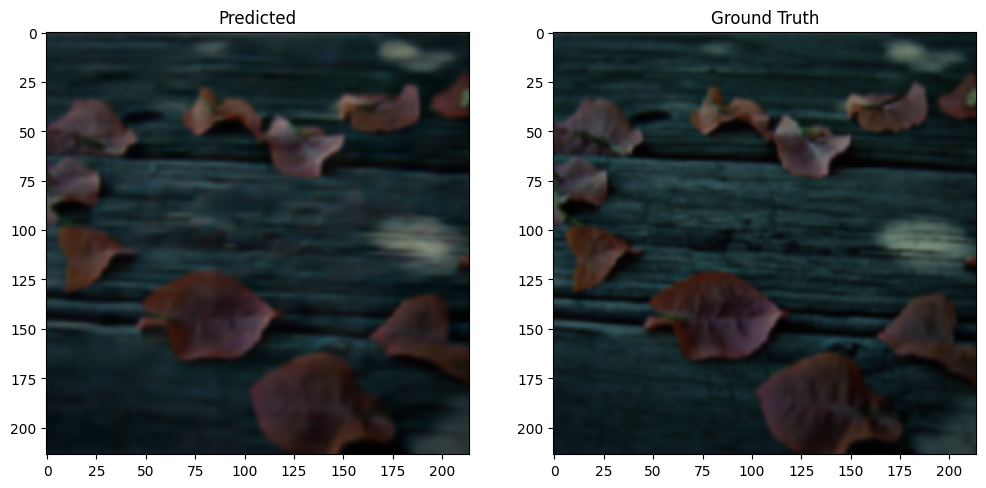

In [5]:
butterfly_img = np.load("/home/ponoma/workspace/Pan_Transformer/infer_results/pan_0.5_rml_6_x4_downsize_3e-05_lr/1.npy", allow_pickle=True)
butterfly_gt = np.load("/home/ponoma/workspace/Pan_Transformer/infer_results/pan_0.5_rml_6_x4_downsize_3e-05_lr/1_gt.npy", allow_pickle=True)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(butterfly_img)
ax[0].set_title("Predicted")
ax[1].imshow(butterfly_gt)
ax[1].set_title("Ground Truth")

In [2]:
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID" 
os.environ["CUDA_VISIBLE_DEVICES"] = '0,1,2'
gpu_number = 1

In [4]:
# dataset type
dataset = 'rml'
size = 0.5
if dataset == 'mirflickr':
    height = 270
else:
    height = 300
width = 480

input_size = (height, width)
model = Rec_Transformer(input_size=input_size, rec_size=(height, width)) 

# model_path = '/home/ponoma/workspace/Pan_Transformer/pan_0.5_rml_6_x4_downsize/latest_model.pth'
#model_path = '/home/ponoma/workspace/Pan_Transformer/latest_model_pan_mirflickr_300k_steps.pth'
model_path = "/home/ponoma/workspace/Pan_Transformer/my_checkpoints/pan_0.5_rml_6_x4_downsize_6e-05_lr/best_model.pth"

if torch.cuda.is_available():
        device = torch.device("cuda")
        torch.cuda.set_device(gpu_number) 
else:
    device = torch.device("cpu")

model.to(device)

# Count trainable parameters
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

# Count all parameters (trainable + frozen)
num_params_total = sum(p.numel() for p in model.parameters())

print(f"Trainable parameters: {num_params}")
print(f"Total parameters: {num_params_total}")

# load in the model
checkpoint = torch.load(model_path, map_location=device, weights_only=True)
loaded_dict = checkpoint['model_state_dict']

model_dict = model.state_dict()
global_step = checkpoint.get('global_step', 'Unknown')
loaded_dict = {k: v for k, v in loaded_dict.items() if k in model_dict}
model_dict.update(loaded_dict)
model.load_state_dict(model_dict) 

print(f"Loaded model from {model_path} at step {global_step}")

Trainable parameters: 16107304
Total parameters: 16107304
Loaded model from /home/ponoma/workspace/Pan_Transformer/my_checkpoints/pan_0.5_rml_6_x4_downsize_6e-05_lr/best_model.pth at step 130000


Processing image 1...


/home/ponoma/miniconda3/envs/LIT/lib/python3.10/site-packages/torch/nn/modules/conv.py:456: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at /opt/conda/conda-bld/pytorch_1712608839953/work/aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv2d(input, weight, bias, self.stride,


Processing image 64...
Processing image 93...
Processing image 195...
Processing image 912...


(-0.5, 200.5, 200.5, -0.5)

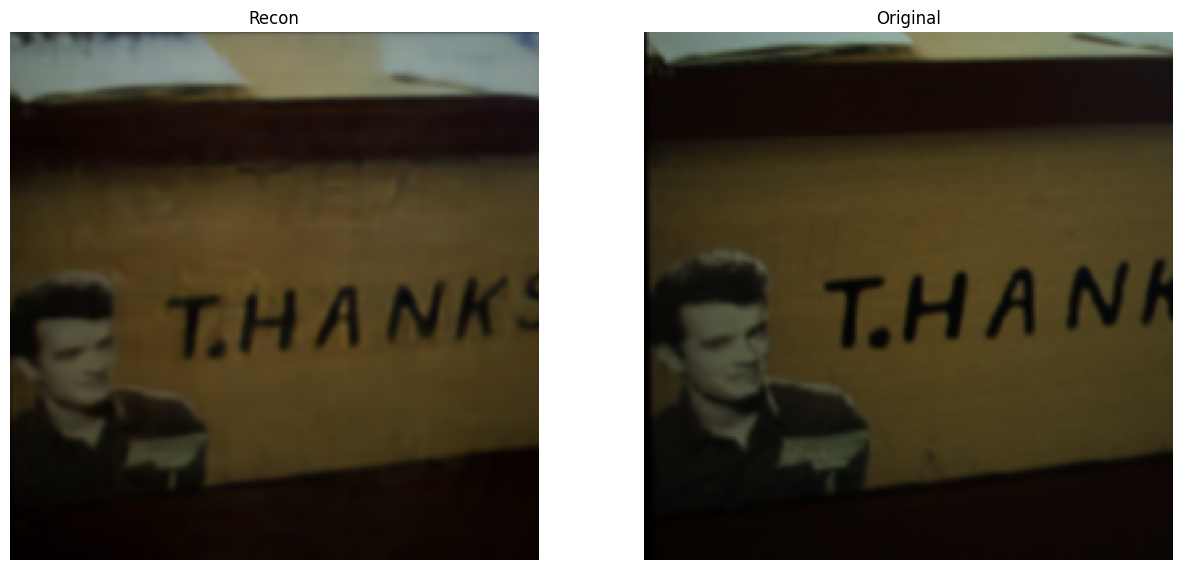

In [5]:
img_numbers = [1, 64, 93, 195, 912]
save_results = False
model_type = 'pan_transformer'

if dataset == 'mirflickr':
        img_numbers = [i+1 for i in img_numbers]
downsize_coeff = 4

if dataset != "mirflickr":
    homography_matrix = torch.load("/home/ponoma/workspace/Lensless_Image_Reconstruction/data/GT2RML_homography_x4_color_detached.npy").to(torch.float32).to(device)
    homography_matrix = torch.inverse(homography_matrix)

model.eval()
for img_number in img_numbers:
    print(f"Processing image {img_number}...") 

    if dataset == "rml":
        # image = tifffile.imread(f"/home/lakabuli/cosmos_drive/dataset100k/rml/img_{img_number}_cam_1.tiff")     # Already in RGB format
        # target = tifffile.imread(f"/home/lakabuli/cosmos_drive/dataset100k/undistorted_images/undistorted_img_{img_number}_cam_2.tiff")
        root_dir = "/home/lakabuli/4tb_patrick/dataset100k26"
        image = tifffile.imread(os.path.join(root_dir, f"4x_rml/4x_img_{img_number}_cam_1.tiff"))
        target = tifffile.imread(os.path.join(root_dir, f"4x_undistorted_GT2RML/warped_4x_undistorted_img_{img_number}_cam_2.tiff"))

        if image.shape[-1] == 4:
            image = image[..., :-1]
        if target.shape[-1] == 4:
            target = target[..., :-1]

        image = (image/255).astype(np.float32)     # max of measurements is 255. Normalizing to range [0, 1]
        target = (target/255).astype(np.float32)

        height, width = image.shape[:2]
        # image = resize(image, (height//downsize_coeff, width//downsize_coeff), anti_aliasing=True).astype(np.float32) 
        # target = resize(target, (height//downsize_coeff, width//downsize_coeff), anti_aliasing=True).astype(np.float32)

        image = np.clip(image, 0,1)
        target = np.clip(target, 0,1)

    elif dataset == "mirflickr":
        image = np.load(f'/home/ponoma/workspace/DATA/mirflickr_dataset/diffuser_images_npy/im{img_number}.npy')[..., ::-1]   # using numpy images that were saved in BGR format instead of RGB
        target = np.load(f'/home/ponoma/workspace/DATA/mirflickr_dataset/ground_truth_lensed_npy/im{img_number}.npy')[..., ::-1] 

        image = np.clip(np.flipud(image)/0.9, 0,1)     # max of measurements is 0.9. Normalizing to range [0, 1]                                 
        target = np.clip(np.flipud(target), 0,1) 

    image = torch.from_numpy(image).permute(2, 0, 1).unsqueeze(0).to(device) # Shape: (1, 3, H, W)
    target = torch.from_numpy(target).permute(2, 0, 1).unsqueeze(0).to(device)

    # fig, ax = plt.subplots(1, 2, figsize=(15,10))
    # ax[0].imshow(image.permute(0, 2, 3, 1).squeeze().cpu())
    # ax[0].set_title('Recon')
    # ax[0].axis('off')

    # ax[1].imshow(target.permute(0, 2, 3, 1).squeeze().cpu())
    # ax[1].set_title('Original')
    # ax[1].axis('off')

    # break

    reconstructed_channels = []
    with torch.no_grad():
        for c in range(3):
            single_channel_in = image[:, c, :, :].unsqueeze(1)

            #single_channel_in = (single_channel_in - single_channel_in.mean()) / single_channel_in.std()
            single_channel_out = model(single_channel_in.float())

            # single_channel_out, _ = crop_borders((single_channel_out, single_channel_out), dataset, downsize_coeff, batch=True)

            single_channel_out = torch.clamp(single_channel_out, 0, 1)
            reconstructed_channels.append(single_channel_out)

        # 5. Recombine Channels
        # Stack along dim 1 to get (1, 3, H, W)
        output = torch.cat(reconstructed_channels, dim=1)

        # RML -> GT transformation
        if dataset != "mirflickr":
            output = transform.warp_perspective(output.float(), homography_matrix, 
                                                dsize=(output.shape[2], output.shape[3])).squeeze()         # last two dimensions should be height and width
        output = torch.clamp(output, 0, 1)

    out_img = output.squeeze().cpu().permute(1, 2, 0).numpy()
    target_img = target.squeeze().cpu().permute(1, 2, 0).numpy()

    if dataset != "mirflickr":
        out_img_no_border_crop = out_img[52:253, 130:331, :]           # this is in ground truth space
        target_no_border_crop = target_img[52:253, 130:331, :]

        out_img_with_border_crop = out_img[48:257, 124:333, :]
        target_with_border_crop = target_img[48:257, 124:333, :]
    elif dataset == "mirflickr":
        out_img_no_border_crop = out_img[60:,62:-38,:]
        target_no_border_crop = target_img[60:,62:-38,:]

    if save_results:
        if dataset != 'mirflickr':
            save_dir = f'/home/ponoma/workspace/Lensless_Image_Reconstruction/imgs_for_paper/{model_type}_{dataset}_{int(size * 100)}k_x{downsize_coeff}_downsample'
            os.makedirs(save_dir, exist_ok=True)
            np.save(f"{save_dir}/{img_number}_with_border_crop.npy", out_img_with_border_crop)
            np.save(f"{save_dir}/{img_number}_no_border_crop.npy", out_img_no_border_crop)
            np.save(f"{save_dir}/{img_number}_uncropped.npy", out_img)
        else:
            save_dir = f'/home/ponoma/workspace/Lensless_Image_Reconstruction/imgs_for_paper/{model_type}_{dataset}_mse'
            os.makedirs(save_dir, exist_ok=True)
            np.save(f"{save_dir}/{img_number}_no_border_crop.npy", out_img_no_border_crop)
            np.save(f"{save_dir}/{img_number}_uncropped.npy", out_img)

fig, ax = plt.subplots(1, 2, figsize=(15,10))
ax[0].imshow(out_img_no_border_crop)
ax[0].set_title('Recon')
ax[0].axis('off')

ax[1].imshow(target_no_border_crop)
ax[1].set_title('Original')
ax[1].axis('off')

## Calculating metrics for rml dataset

In [5]:
# 2. Define the scenarios we want to track
scenarios = ['rml_space', 'gt_no_border_crop', 'gt_with_border_crop']

# 3. Initialize separate metric objects for each scenario
metrics_tracker = {}
for name in scenarios:
    metrics_tracker[name] = {
        'psnr_obj': PSNR(data_range=1.0).to('cpu'),
        'ssim_obj': SSIM(data_range=1.0).to('cpu'),
        'total_mse': 0.0,
        'total_loss': 0.0,
        'total_lpips': 0.0,
        'count': 0
    }

# LPIPS is stateless, one instance is fine
lpips = LPIPS(net_type='alex', normalize=True).to('cpu') 

def update_scenario(name, pred_batch, target_batch):
    """Helper to update metrics for a specific scenario"""
    # Move to CPU for metric calculation
    pred_cpu = pred_batch.detach().cpu()
    target_cpu = target_batch.detach().cpu()

    # Update stateful metrics (PSNR, SSIM)
    metrics_tracker[name]['psnr_obj'].update(pred_cpu, target_cpu)
    metrics_tracker[name]['ssim_obj'].update(pred_cpu, target_cpu)
    
    # Update accumulators
    mse_val = torch.nn.functional.mse_loss(pred_cpu, target_cpu, reduction="mean").item()
    loss_val = torch.nn.functional.mse_loss(pred_batch, target_batch).item() # Calculate loss on GPU/device if possible for consistency with original code
    
    metrics_tracker[name]['total_mse'] += mse_val
    metrics_tracker[name]['total_loss'] += loss_val
    
    # LPIPS Normalization (normalize output to 0-1 range based on its own min/max)
    output_min = torch.min(pred_cpu)
    diff = torch.max(pred_cpu) - output_min
    if diff > 0:
        pred_norm = (pred_cpu - output_min) / diff
    else:
        pred_norm = pred_cpu
        
    metrics_tracker[name]['total_lpips'] += lpips(pred_norm, target_cpu).item()
    metrics_tracker[name]['count'] += 1

print("Starting inference for both border scenarios...")

with torch.no_grad():
    model.eval()

    for img_number in tqdm(range(2, 1002)):
        if dataset == "rml":
            image = tifffile.imread(f"/home/lakabuli/cosmos_drive/dataset100k/rml/img_{img_number}_cam_1.tiff")     # Already in RGB format
            target = tifffile.imread(f"/home/lakabuli/cosmos_drive/dataset100k/undistorted_images/undistorted_img_{img_number}_cam_2.tiff")
        
        elif dataset == 'diffusercam':
            image = tifffile.imread(f"/home/clara/4tb_patrick/dataset100k/diffusercam/img_{img_number}_cam_0.tiff")
            target = tifffile.imread(f"/home/lakabuli/cosmos_drive/dataset100k/undistorted_images/undistorted_img_{img_number}_cam_2.tiff")

        if image.shape[-1] == 4:
            image = image[..., :-1]
        if target.shape[-1] == 4:
            target = target[..., :-1]

        if np.max(image) > 1.0:
            image = (image/255).astype(np.float32)     
        if np.max(target) > 1.0:
            target = (target/255).astype(np.float32)

        height_original, width_original = image.shape[:2]
        image = resize(image, (height_original//downsize_coeff, width_original//downsize_coeff), anti_aliasing=True).astype(np.float32) 
        image = np.clip(image, 0,1)

        if dataset == 'rml' or dataset == 'diffusercam':
            target = resize(target, (height_original//downsize_coeff, width_original//downsize_coeff), anti_aliasing=True).astype(np.float32)

        image = torch.from_numpy(image).permute(2, 0, 1).unsqueeze(0) # Shape: (1, 3, H, W)
        target = torch.from_numpy(target).permute(2, 0, 1).unsqueeze(0)

        image, target = image.to(device), target.to(device)

        reconstructed_channels = []
        for c in range(3):
            single_channel_in = image[:, c, :, :].unsqueeze(1)
            single_channel_out = model(single_channel_in.float())

            single_channel_out = torch.clamp(single_channel_out, 0, 1)
            reconstructed_channels.append(single_channel_out)
            
        output = torch.cat(reconstructed_channels, dim=1)
        output = torch.clamp(output, 0, 1)

        # --- SCENARIO 1: With Borders (Raw Output) ---
        out_rml, tgt_rml = crop_borders((output, target), dataset, downsize_coeff, batch=True)
        update_scenario('rml_space', out_rml, tgt_rml)

        # --- SCENARIO 2 & 3: GT Space (Homography) ---
        if dataset != 'mirflickr':
            # Warp ONCE
            out_warped = transform.warp_perspective(output.float(), homography_matrix, 
                                                    dsize=(output.shape[2], output.shape[3]))
            out_warped = torch.clamp(out_warped, 0, 1)

            # tgt_warped = transform.warp_perspective(target.float(), homography_matrix,                # if using undistorted, original ground truth images, no need to warp. They are already in GT space
            #                                         dsize=(target.shape[2], target.shape[3]))
            # tgt_warped = torch.clamp(tgt_warped, 0, 1)

            # No Border Crop
            out_no_border = out_warped[:, :, 52:253, 130:331]
            tgt_no_border = target[:, :, 52:253, 130:331]
            update_scenario('gt_no_border_crop', out_no_border, tgt_no_border)

            # With Border Crop
            out_with_border = out_warped[:, :, 48:257, 124:333]
            tgt_with_border = target[:, :, 48:257, 124:333]
            update_scenario('gt_with_border_crop', out_with_border, tgt_with_border)

        # fig, ax = plt.subplots(1, 2, figsize=(15,10))
        # ax[0].imshow(out_with_border.permute(0, 2, 3, 1).squeeze().cpu())
        # ax[0].set_title('Recon')
        # ax[0].axis('off')

        # ax[1].imshow(tgt_with_border.permute(0, 2, 3, 1).squeeze().cpu())
        # ax[1].set_title('Original')
        # ax[1].axis('off')

        # break


# --- Final Calculation & Saving ---
final_results = {}
final_results["model_saved"] = model_path # Save the model path once at the top level

print(f"\nResults for {model_path}:")

for name in scenarios:
    count = metrics_tracker[name]['count']
    if count == 0: continue

    # Compute averages
    # Note: Using len(test_loader.dataset) if batch_size=1, otherwise use actual count of batches processed 
    # Original code divided by len(dataset), assuming step count equals dataset length (batch_size=1?)
    # If batch_size > 1, you might want to divide by 'count' (number of batches) or ensure summation logic matches
    
    # Assuming batch_size=1 based on your original dividing by len(test_loader.dataset)
    # If batch_size > 1, you should technically weigh the average or just divide accumulators by `count` (number of batches) 
    divisor = 1000
    
    avg_loss = metrics_tracker[name]['total_loss'] / divisor
    avg_mse = metrics_tracker[name]['total_mse'] / divisor
    avg_lpips = metrics_tracker[name]['total_lpips'] / divisor
    
    avg_psnr = metrics_tracker[name]['psnr_obj'].compute().item()
    avg_ssim = metrics_tracker[name]['ssim_obj'].compute().item()

    # Reset objects
    metrics_tracker[name]['psnr_obj'].reset()
    metrics_tracker[name]['ssim_obj'].reset()

    # Store in dictionary under the specific scenario key
    final_results[name] = {
        'Loss': avg_loss,
        'PSNR': avg_psnr,
        'SSIM': avg_ssim,
        'MSE': avg_mse,
        'LPIPS': avg_lpips
    }

    print(f"\n--- {name} ---")
    print(f"Avg. MSE Loss: {avg_loss:.6f}")
    print(f"Avg. PSNR: {avg_psnr:.4f}")
    print(f"Avg. SSIM: {avg_ssim:.4f}")
    print(f"Avg. MSE: {avg_mse:.6f}")
    print(f"Avg. LPIPS: {avg_lpips:.6f}")

# Save to NPY file
save_file = f"metrics.npy"
np.save(save_file, final_results)
print(f"\nAll metrics saved to {save_file}")

Starting inference for both border scenarios...


100%|██████████| 1000/1000 [15:06<00:00,  1.10it/s]


Results for /home/ponoma/workspace/Pan_Transformer/pan_0.5_rml_6_x4_downsize/latest_model.pth:

--- rml_space ---
Avg. MSE Loss: 0.083444
Avg. PSNR: 10.7860
Avg. SSIM: 0.3247
Avg. MSE: 0.083444
Avg. LPIPS: 0.510690

--- gt_no_border_crop ---
Avg. MSE Loss: 0.049062
Avg. PSNR: 13.0925
Avg. SSIM: 0.5984
Avg. MSE: 0.049062
Avg. LPIPS: 0.394988

--- gt_with_border_crop ---
Avg. MSE Loss: 0.046847
Avg. PSNR: 13.2932
Avg. SSIM: 0.6010
Avg. MSE: 0.046847
Avg. LPIPS: 0.388422

All metrics saved to metrics.npy


# Calculating RML Image metrics

In [ ]:
## Debugging image metric calculations

def confidence_interval_list(data_list, confidence_interval=0.95):
    # can also use confidence interval 0.9 or 0.99 if want slightly different bounds
    error_lo = np.percentile(data_list, 100 * (1 - confidence_interval) / 2)
    error_hi = np.percentile(data_list, 100 * (1 - (1 - confidence_interval) / 2))
    mean = np.mean(data_list)
    return error_lo, error_hi, mean

# LPIPS is stateless, one instance is fine
lpips = LPIPS(net_type='alex', normalize=True).to('cpu') 
psnr = PSNR(data_range=1.0)
ssim = SSIM(data_range=1.0)

with torch.no_grad():
    model.eval()

    total_loss = []
    total_mse = []
    total_lpips = []
    total_psnr = []
    total_ssim = []

    for img_number in tqdm(range(2, 1002)):
        if dataset == "rml":
            image = tifffile.imread(f"/home/lakabuli/cosmos_drive/dataset100k/rml/img_{img_number}_cam_1.tiff")     # Already in RGB format
            #target = tifffile.imread(f"/home/lakabuli/cosmos_drive/dataset100k/undistorted_images/undistorted_img_{img_number}_cam_2.tiff")
            target = tifffile.imread(f"/home/clara/4tb_patrick/dataset100k/4x_warped_ground_truth/warped_undistorted_img_{img_number}_cam_2.tiff")
        
        elif dataset == 'diffusercam':
            image = tifffile.imread(f"/home/clara/4tb_patrick/dataset100k/diffusercam/img_{img_number}_cam_0.tiff")
            target = tifffile.imread(f"/home/lakabuli/cosmos_drive/dataset100k/undistorted_images/undistorted_img_{img_number}_cam_2.tiff")

        if image.shape[-1] == 4:
            image = image[..., :-1]
        if target.shape[-1] == 4:
            target = target[..., :-1]

        if np.max(image) > 1.0:
            image = (image/255).astype(np.float32)     
        if np.max(target) > 1.0:
            target = (target/255).astype(np.float32)

        height_original, width_original = image.shape[:2]
        image = resize(image, (height_original//downsize_coeff, width_original//downsize_coeff), anti_aliasing=True).astype(np.float32) 
        image = np.clip(image, 0,1)

        if dataset == 'diffusercam':
            target = resize(target, (height_original//downsize_coeff, width_original//downsize_coeff), anti_aliasing=True).astype(np.float32)
            target = np.clip(target, 0,1)

        image = torch.from_numpy(image).permute(2, 0, 1).unsqueeze(0) # Shape: (1, 3, H, W)
        target = torch.from_numpy(target).permute(2, 0, 1).unsqueeze(0)

        image, target = image.to(device), target.to(device)

        reconstructed_channels = []
        for c in range(3):
            single_channel_in = image[:, c, :, :].unsqueeze(1)
            single_channel_out = model(single_channel_in.float())

            single_channel_out = torch.clamp(single_channel_out, 0, 1)
            reconstructed_channels.append(single_channel_out)
            
        output = torch.cat(reconstructed_channels, dim=1)
        output = torch.clamp(output, 0, 1)

        # --- GT Space (Homography) ---
        out_warped = transform.warp_perspective(output.float(), homography_matrix, 
                                                dsize=(output.shape[2], output.shape[3]))
        out_warped = torch.clamp(out_warped, 0, 1)

        tgt_warped = transform.warp_perspective(target.float(), homography_matrix,                # if using undistorted, original ground truth images, no need to warp. They are already in GT space
                                                dsize=(target.shape[2], target.shape[3]))
        tgt_warped = torch.clamp(tgt_warped, 0, 1)

        # No Border Crop
        output = out_warped[:, :, 52:253, 130:331]
        target = tgt_warped[:, :, 52:253, 130:331]

        # fig, ax = plt.subplots(1, 2, figsize=(15,10))
        # ax[0].imshow(output.permute(0, 2, 3, 1).squeeze().cpu())
        # ax[0].set_title('Recon')
        # ax[0].axis('off')

        # ax[1].imshow(target.permute(0, 2, 3, 1).squeeze().cpu())
        # ax[1].set_title('Original')
        # ax[1].axis('off')

        # break

        loss = torch.nn.functional.mse_loss(output, target)  
        total_loss.append(loss.item()) 

        output_cpu = output.detach().cpu()
        target_cpu = target.detach().cpu()
        total_psnr.append(psnr(output_cpu, target_cpu).item())
        total_ssim.append(ssim(output_cpu, target_cpu).item())

        total_mse.append(torch.nn.functional.mse_loss(output_cpu, target_cpu, reduction="mean").item())      

        # LPIPS only accepts images in range [0, 1] or [-1, 1], so we normalize to [0, 1] because that is our ground truth range
        output_min = torch.min(output_cpu)
        output_cpu = (output_cpu - output_min)/ (torch.max(output_cpu) - output_min + 1e-8)
        total_lpips.append(lpips(output_cpu, target_cpu).item())    

    assert len(total_loss) == len(total_loss)
    avg_loss = sum(total_loss) / len(total_loss) 
    avg_mse = sum(total_mse) / len(total_mse)
    avg_lpips = sum(total_lpips) / len(total_lpips) 
    avg_psnr = sum(total_psnr) / len(total_psnr)
    avg_ssim = sum(total_ssim) / len(total_ssim) 

    confidence_interval_mse = confidence_interval_list(total_mse)
    confidence_interval_lpips = confidence_interval_list(total_lpips)
    confidence_interval_psnr = confidence_interval_list(total_psnr)
    confidence_interval_ssim = confidence_interval_list(total_ssim)

    final_results = {
        "avg_mse": avg_mse,
        "avg_lpips": avg_lpips,
        "avg_psnr": avg_psnr,
        "avg_ssim": avg_ssim,
        "confidence_interval_mse": confidence_interval_mse,
        "confidence_interval_lpips": confidence_interval_lpips,
        "confidence_interval_psnr": confidence_interval_psnr,
        "confidence_interval_ssim": confidence_interval_ssim}

    if save_results:
        save_dir = f"/home/ponoma/workspace/Lensless_Image_Reconstruction/imgs_for_paper/{model_type}_{dataset}_{size}"
        os.makedirs(save_dir, exist_ok=True)
        np.save(f"{save_dir}/metrics_list.npy", final_results)

    print(f"\nFor {model_path} model")
    print(f"Avg. MSE Loss: {avg_loss}")
    print(f"Avg. PSNR: {avg_psnr}")
    print(f"Avg. SSIM: {avg_ssim}")
    print(f"Avg. MSE: {avg_mse}")
    print(f"Avg. LPIPS: {avg_lpips}")

    print(f"Confidence Interval for MSE: {confidence_interval_mse}")
    print(f"Confidence Interval for LPIPS: {confidence_interval_lpips}")
    print(f"Confidence Interval for PSNR: {confidence_interval_psnr}")
    print(f"Confidence Interval for SSIM: {confidence_interval_ssim}")

100%|██████████| 1000/1000 [11:48<00:00,  1.41it/s]


For /home/ponoma/workspace/Pan_Transformer/pan_0.5_rml_6_x4_downsize/latest_model.pth model
Avg. MSE Loss: 0.01612306579167489
Avg. PSNR: 19.17733734035492
Avg. SSIM: 0.6701952255293727
Avg. MSE: 0.016123064997955225
Avg. LPIPS: 0.3179871530979872
Confidence Interval for MSE: (0.0034961737459525476, 0.05356977554038167, 0.016123064997955225)
Confidence Interval for LPIPS: (0.14032755792140963, 0.6177086636424064, 0.3179871530979872)
Confidence Interval for PSNR: (12.710801100730896, 24.564075708389282, 19.17733734035492)
Confidence Interval for SSIM: (0.3900825202465058, 0.8856578469276428, 0.6701952255293727)


## Calculating metrics for Kristina Dataset

In [14]:
save_path = "/home/ponoma/workspace/Pan_Transformer/latest_model_pan_mirflickr_300k_steps.pth"

# 2. Define the scenarios
scenarios = ['with_borders', 'without_borders']

# 3. Initialize separate metric objects for each scenario
metrics_tracker = {}
for name in scenarios:
    metrics_tracker[name] = {
        'psnr_obj': PSNR(data_range=1.0).to('cpu'),
        'ssim_obj': SSIM(data_range=1.0).to('cpu'),
        'total_mse': 0.0,
        'total_loss': 0.0,
        'total_lpips': 0.0,
        'count': 0
    }

# LPIPS is stateless, one instance is fine
lpips = LPIPS(net_type='alex', normalize=True).to('cpu') 

def update_scenario(name, pred_batch, target_batch):
    """Helper to update metrics for a specific scenario"""
    # Move to CPU for metric calculation
    pred_cpu = pred_batch.detach().cpu()
    target_cpu = target_batch.detach().cpu()

    # Update stateful metrics (PSNR, SSIM)
    metrics_tracker[name]['psnr_obj'].update(pred_cpu, target_cpu)
    metrics_tracker[name]['ssim_obj'].update(pred_cpu, target_cpu)
    
    # Update accumulators
    mse_val = torch.nn.functional.mse_loss(pred_cpu, target_cpu, reduction="mean").item()
    loss_val = torch.nn.functional.mse_loss(pred_batch, target_batch).item() # Calculate loss on GPU/device if possible for consistency with original code
    
    metrics_tracker[name]['total_mse'] += mse_val
    metrics_tracker[name]['total_loss'] += loss_val
    
    # LPIPS Normalization (normalize output to 0-1 range based on its own min/max)
    output_min = torch.min(pred_cpu)
    diff = torch.max(pred_cpu) - output_min
    if diff > 0:
        pred_norm = (pred_cpu - output_min) / diff
    else:
        pred_norm = pred_cpu
        
    metrics_tracker[name]['total_lpips'] += lpips(pred_norm, target_cpu).item()
    metrics_tracker[name]['count'] += 1

print("Starting inference for both border scenarios...")

with torch.no_grad():
    model.eval()

    for img_number in tqdm(range(2, 1002)):
        image = np.load(f"/home/ponoma/workspace/DATA/mirflickr_dataset/diffuser_images_npy/im{img_number}.npy")[..., ::-1]  
        target = np.load(f"/home/ponoma/workspace/DATA/mirflickr_dataset/ground_truth_lensed_npy/im{img_number}.npy")[..., ::-1] 

        image = np.clip(np.flipud(image)/0.9, 0,1)     # max of measurements is 0.9. Normalizing to range [0, 1]                                 
        target = np.clip(np.flipud(target), 0,1) 

        image = torch.from_numpy(image).permute(2, 0, 1).unsqueeze(0).to(device) # Shape: (1, 3, H, W)
        target = torch.from_numpy(target).permute(2, 0, 1).unsqueeze(0).to(device)

        image, target = image.to(device), target.to(device)

        reconstructed_channels = []
        for c in range(3):
            single_channel_in = image[:, c, :, :].unsqueeze(1)

            #single_channel_in = (single_channel_in - single_channel_in.mean()) / single_channel_in.std()
            single_channel_out = model(single_channel_in.float())
            # single_channel_out, _ = crop_borders((single_channel_out, single_channel_out), dataset, downsize_coeff, batch=True)

            single_channel_out = torch.clamp(single_channel_out, 0, 1)
            reconstructed_channels.append(single_channel_out)
            
        output = torch.cat(reconstructed_channels, dim=1)
        output = torch.clamp(output, 0, 1)

        # --- SCENARIO 1: With Borders (Raw Output) ---
        update_scenario('with_borders', output, target)

        # --- SCENARIO 2: Without Borders (Cropped) ---
        output_cropped = output[:,:,60:,62:-38]
        target_cropped = target[:,:,60:,62:-38]
        update_scenario('without_borders', output_cropped, target_cropped)

        # fig, ax = plt.subplots(1, 2, figsize=(15,10))
        # ax[0].imshow(output_cropped.permute(0, 2, 3, 1).squeeze().cpu())
        # ax[0].set_title('Recon')
        # ax[0].axis('off')

        # ax[1].imshow(target_cropped.permute(0, 2, 3, 1).squeeze().cpu())
        # ax[1].set_title('Original')
        # ax[1].axis('off')

        # break


# --- Final Calculation & Saving ---
final_results = {}
final_results["model_saved"] = save_path # Save the model path once at the top level

print(f"\nResults for {save_path}:")

for name in scenarios:
    count = metrics_tracker[name]['count']
    if count == 0: continue

    # Compute averages
    # Note: Using len(test_loader.dataset) if batch_size=1, otherwise use actual count of batches processed 
    # Original code divided by len(dataset), assuming step count equals dataset length (batch_size=1?)
    # If batch_size > 1, you might want to divide by 'count' (number of batches) or ensure summation logic matches
    
    # Assuming batch_size=1 based on your original dividing by len(test_loader.dataset)
    # If batch_size > 1, you should technically weigh the average or just divide accumulators by `count` (number of batches) 
    divisor = 1000
    
    avg_loss = metrics_tracker[name]['total_loss'] / divisor
    avg_mse = metrics_tracker[name]['total_mse'] / divisor
    avg_lpips = metrics_tracker[name]['total_lpips'] / divisor
    
    avg_psnr = metrics_tracker[name]['psnr_obj'].compute().item()
    avg_ssim = metrics_tracker[name]['ssim_obj'].compute().item()

    # Reset objects
    metrics_tracker[name]['psnr_obj'].reset()
    metrics_tracker[name]['ssim_obj'].reset()

    # Store in dictionary under the specific scenario key
    final_results[name] = {
        'Loss': avg_loss,
        'PSNR': avg_psnr,
        'SSIM': avg_ssim,
        'MSE': avg_mse,
        'LPIPS': avg_lpips
    }

    print(f"\n--- {name} ---")
    print(f"Avg. MSE Loss: {avg_loss:.6f}")
    print(f"Avg. PSNR: {avg_psnr:.4f}")
    print(f"Avg. SSIM: {avg_ssim:.4f}")
    print(f"Avg. MSE: {avg_mse:.6f}")
    print(f"Avg. LPIPS: {avg_lpips:.6f}")

# Save to NPY file
save_file = f"metrics.npy"
np.save(save_file, final_results)
print(f"\nAll metrics saved to {save_file}")

Starting inference for both border scenarios...


100%|██████████| 1000/1000 [09:46<00:00,  1.71it/s]


Results for /home/ponoma/workspace/Pan_Transformer/latest_model_pan_mirflickr_300k_steps.pth:

--- with_borders ---
Avg. MSE Loss: 0.064696
Avg. PSNR: 11.8912
Avg. SSIM: 0.4698
Avg. MSE: 0.064696
Avg. LPIPS: 0.562713

--- without_borders ---
Avg. MSE Loss: 0.008238
Avg. PSNR: 20.8415
Avg. SSIM: 0.6356
Avg. MSE: 0.008238
Avg. LPIPS: 0.422900

All metrics saved to metrics.npy


# Calculating individual image metrics

PSNR:  19.756742477416992
SSIM:  0.5280298590660095
MSE Loss:  0.010576105676591396
LPIPS:  0.2510201930999756


PSNR:  19.75813865661621
SSIM:  0.5092125535011292
MSE Loss:  0.010572703555226326
LPIPS:  0.2400297224521637


PSNR:  19.6613712310791
SSIM:  0.522229790687561
MSE Loss:  0.010810920968651772
LPIPS:  0.23698996007442474


PSNR:  18.207019805908203
SSIM:  0.6851345300674438
MSE Loss:  0.015111163258552551
LPIPS:  0.22621934115886688


PSNR:  17.73709487915039
SSIM:  0.6824371218681335
MSE Loss:  0.01683799736201763
LPIPS:  0.23352116346359253


PSNR:  17.92951202392578
SSIM:  0.6805103421211243
MSE Loss:  0.01610826887190342
LPIPS:  0.22245250642299652


PSNR:  22.472280502319336
SSIM:  0.6663362383842468
MSE Loss:  0.005659419111907482
LPIPS:  0.3092169463634491


PSNR:  22.21263313293457
SSIM:  0.6555553674697876
MSE Loss:  0.006008094642311335
LPIPS:  0.2771608233451843


PSNR:  22.338130950927734
SSIM:  0.6682028770446777
MSE Loss:  0.005836960393935442
LPIPS:  0.2829229

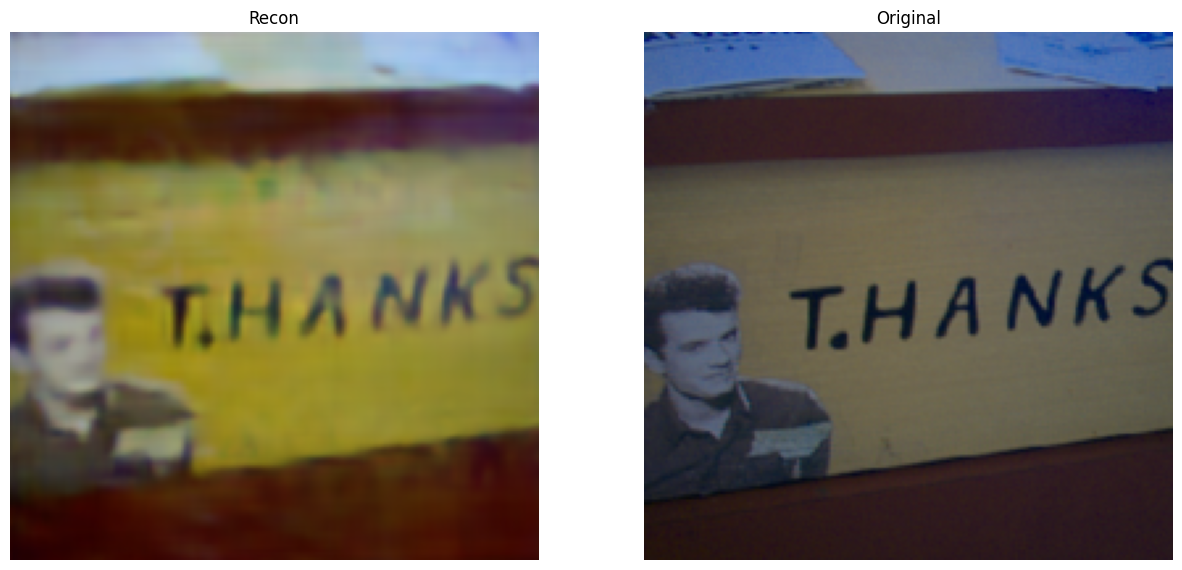

In [10]:
save_results = True

# FOR INFERENCE: apply homography to RECON (RML -> GT)
if downsize_coeff == 4:
    if dataset == "rml":            
        homography_matrix = torch.load("/home/ponoma/workspace/Lensless_Image_Reconstruction/data/GT2RML_homography_x4_color_detached.npy", weights_only=True) 
    elif dataset == 'diffusercam':
        homography_matrix = torch.load("/home/ponoma/workspace/Lensless_Image_Reconstruction/data/GT2DC_homography_x4_color_detached.npy", weights_only=True)
elif dataset == 'efov':
    homography_matrix = torch.load("/home/ponoma/workspace/Lensless_Image_Reconstruction/data/GT2RML_efov_homography_x8_color_detached.npy", weights_only=True).to(torch.float32)

# Need to invert to get RML -> GT warp
homography_matrix = torch.inverse(homography_matrix).to(device)

final_metrics = {}

psnr = PSNR(data_range=1.0).to(device)
ssim = SSIM(data_range=1.0).to(device)
lpips = LPIPS(net_type='alex').to(device)

def calculate_metrics(output, target, scenario, img_number):
    psnr_val = psnr(output, target) 
    ssim_val = ssim(output, target)  
    mse_val = torch.nn.functional.mse_loss(output, target)  # Reduces by default to a scalar
    output_min = torch.min(output)
    if torch.max(output) - output_min > 0:
        output_norm = (output - output_min) / (torch.max(output) - output_min)
    else:
        output_norm = output
    lpips_val = lpips(output_norm, target)

    if img_number not in final_metrics:
        final_metrics[img_number] = {}

    final_metrics[img_number][scenario] = {
        'PSNR': psnr_val.item(),
        'SSIM': ssim_val.item(),
        'MSE': mse_val.item(),
        'LPIPS': lpips_val.item()
    }

    print("PSNR: ", psnr_val.item())       
    print("SSIM: ", ssim_val.item())
    print("MSE Loss: ", mse_val.item())
    print("LPIPS: ", lpips_val.item())
    print("\n")

with torch.no_grad():
    model.eval()

    for img_number in img_numbers:
        if dataset == "rml":
            image = tifffile.imread(f"/home/lakabuli/cosmos_drive/dataset100k/rml/img_{img_number}_cam_1.tiff")     # Already in RGB format
            #target = tifffile.imread(f"/home/lakabuli/cosmos_drive/dataset100k/undistorted_images/undistorted_img_{img_number}_cam_2.tiff")
            target = tifffile.imread(f"/home/clara/4tb_patrick/dataset100k/4x_warped_ground_truth/warped_undistorted_img_{img_number}_cam_2.tiff")
        
        elif dataset == 'diffusercam':
            image = tifffile.imread(f"/home/clara/4tb_patrick/dataset100k/diffusercam/img_{img_number}_cam_0.tiff")
            target = tifffile.imread(f"/home/lakabuli/cosmos_drive/dataset100k/undistorted_images/undistorted_img_{img_number}_cam_2.tiff")

        if image.shape[-1] == 4:
            image = image[..., :-1]
        if target.shape[-1] == 4:
            target = target[..., :-1]

        if np.max(image) > 1.0:
            image = (image/255).astype(np.float32)     
        if np.max(target) > 1.0:
            target = (target/255).astype(np.float32)

        height_original, width_original = image.shape[:2]
        image = resize(image, (height_original//downsize_coeff, width_original//downsize_coeff), anti_aliasing=True).astype(np.float32) 
        image = np.clip(image, 0,1)

        if dataset == 'diffusercam':
            target = resize(target, (height_original//downsize_coeff, width_original//downsize_coeff), anti_aliasing=True).astype(np.float32)
            target = np.clip(target, 0,1)

        image = torch.from_numpy(image).permute(2, 0, 1).unsqueeze(0) # Shape: (1, 3, H, W)
        target = torch.from_numpy(target).permute(2, 0, 1).unsqueeze(0)

        image, target = image.to(device), target.to(device)

        reconstructed_channels = []
        for c in range(3):
            single_channel_in = image[:, c, :, :].unsqueeze(1)
            single_channel_out = model(single_channel_in.float())

            single_channel_out = torch.clamp(single_channel_out, 0, 1)
            reconstructed_channels.append(single_channel_out)
            
        output = torch.cat(reconstructed_channels, dim=1)
        output = torch.clamp(output, 0, 1)

        # --- SCENARIO 1: With Borders (Raw Output) ---
        out_rml, tgt_rml = crop_borders((output, target), dataset, downsize_coeff, batch=True)
        calculate_metrics(out_rml, tgt_rml, 'rml_space', img_number)

        # --- SCENARIO 2 & 3: GT Space (Homography) ---
        # Warp ONCE
        out_warped = transform.warp_perspective(output.float(), homography_matrix, 
                                                dsize=(output.shape[2], output.shape[3]))
        out_warped = torch.clamp(out_warped, 0, 1)

        tgt_warped = transform.warp_perspective(target.float(), homography_matrix,                # if using undistorted, original ground truth images, no need to warp. They are already in GT space
                                                dsize=(target.shape[2], target.shape[3]))
        tgt_warped = torch.clamp(tgt_warped, 0, 1)

        # No Border Crop
        out_no_border = out_warped[:, :, 52:253, 130:331]
        tgt_no_border = tgt_warped[:, :, 52:253, 130:331]
        calculate_metrics(out_no_border, tgt_no_border, 'gt_no_border_crop', img_number)

        # With Border Crop
        out_with_border = out_warped[:, :, 48:257, 124:333]
        tgt_with_border = tgt_warped[:, :, 48:257, 124:333]
        calculate_metrics(out_with_border, tgt_with_border, 'gt_with_border_crop', img_number)

        # fig, ax = plt.subplots(1, 2, figsize=(15,10))
        # ax[0].imshow(out_with_border.permute(0, 2, 3, 1).squeeze().cpu())
        # ax[0].set_title('Recon')
        # ax[0].axis('off')

        # ax[1].imshow(tgt_with_border.permute(0, 2, 3, 1).squeeze().cpu())
        # ax[1].set_title('Original')
        # ax[1].axis('off')

        # break


# --- Final Calculation & Saving ---
if save_results:
    save_dir = f'/home/ponoma/workspace/Lensless_Image_Reconstruction/imgs_for_paper/{model_type}_{dataset}_{int(size * 100)}k_x{downsize_coeff}_downsample'
    os.makedirs(save_dir, exist_ok=True)
    # np.save(f"{save_dir}/{img_number}_with_border_crop.npy", out_img_with_border_crop)
    # np.save(f"{save_dir}/{img_number}_no_border_crop.npy", out_img_no_border_crop)
    # np.save(f"{save_dir}/{img_number}_uncropped.npy", out_img)

    np.save(f"{save_dir}/indiv_imgs_final_metrics.npy", final_metrics)
        

fig, ax = plt.subplots(1, 2, figsize=(15,10))
ax[0].imshow(out_img_no_border_crop)
ax[0].set_title('Recon')
ax[0].axis('off')

ax[1].imshow(target_no_border_crop)
ax[1].set_title('Original')
ax[1].axis('off')

plt.show()

## For mirflickr dataset

PSNR:  19.377771377563477
SSIM:  0.4856736958026886
MSE Loss:  0.011540450155735016
LPIPS:  0.341549277305603


PSNR:  21.276517868041992
SSIM:  0.6573207974433899
MSE Loss:  0.007453291676938534
LPIPS:  0.27523139119148254


PSNR:  21.47934341430664
SSIM:  0.6145266890525818
MSE Loss:  0.007113208528608084
LPIPS:  0.3821798861026764


PSNR:  19.191362380981445
SSIM:  0.5543467998504639
MSE Loss:  0.012046578340232372
LPIPS:  0.3916434347629547


PSNR:  20.944812774658203
SSIM:  0.6358781456947327
MSE Loss:  0.008044862188398838
LPIPS:  0.36313146352767944




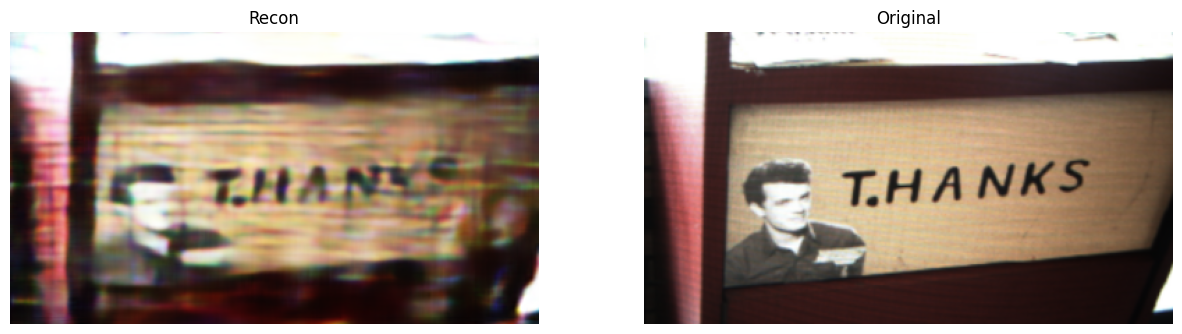

In [9]:
save_path = "/home/ponoma/workspace/Pan_Transformer/latest_model_pan_mirflickr_300k_steps.pth"
save_results = True

final_metrics = {}

psnr = PSNR(data_range=1.0).to(device)
ssim = SSIM(data_range=1.0).to(device)
lpips = LPIPS(net_type='alex').to(device)

with torch.no_grad():
    model.eval()

    for img_number in img_numbers:
        image = np.load(f"/home/ponoma/workspace/DATA/mirflickr_dataset/diffuser_images_npy/im{img_number}.npy")[..., ::-1]  
        target = np.load(f"/home/ponoma/workspace/DATA/mirflickr_dataset/ground_truth_lensed_npy/im{img_number}.npy")[..., ::-1] 

        image = np.clip(np.flipud(image)/0.9, 0,1)     # max of measurements is 0.9. Normalizing to range [0, 1]                                 
        target = np.clip(np.flipud(target), 0,1) 

        image = torch.from_numpy(image).permute(2, 0, 1).unsqueeze(0).to(device) # Shape: (1, 3, H, W)
        target = torch.from_numpy(target).permute(2, 0, 1).unsqueeze(0).to(device)

        image, target = image.to(device), target.to(device)

        reconstructed_channels = []
        for c in range(3):
            single_channel_in = image[:, c, :, :].unsqueeze(1)

            #single_channel_in = (single_channel_in - single_channel_in.mean()) / single_channel_in.std()
            single_channel_out = model(single_channel_in.float())
            # single_channel_out, _ = crop_borders((single_channel_out, single_channel_out), dataset, downsize_coeff, batch=True)

            single_channel_out = torch.clamp(single_channel_out, 0, 1)
            reconstructed_channels.append(single_channel_out)
            
        output = torch.cat(reconstructed_channels, dim=1)
        output = torch.clamp(output, 0, 1)

        output_cropped = output[:,:,60:,62:-38]
        target_cropped = target[:,:,60:,62:-38]
        
        psnr_val = psnr(output_cropped, target_cropped) 
        ssim_val = ssim(output_cropped, target_cropped)  
        mse_val = torch.nn.functional.mse_loss(output_cropped, target_cropped)  # Reduces by default to a scalar
        output_min = torch.min(output_cropped)
        if torch.max(output_cropped) - output_min > 0:
            output_norm = (output_cropped - output_min) / (torch.max(output_cropped) - output_min)
        else:
            output_norm = output_cropped
        lpips_val = lpips(output_norm, target_cropped)

        final_metrics[img_number] = {
            'PSNR': psnr_val.item(),
            'SSIM': ssim_val.item(),
            'MSE': mse_val.item(),
            'LPIPS': lpips_val.item()
        }

        print("PSNR: ", psnr_val.item())       
        print("SSIM: ", ssim_val.item())
        print("MSE Loss: ", mse_val.item())
        print("LPIPS: ", lpips_val.item())
        print("\n")

        # fig, ax = plt.subplots(1, 2, figsize=(15,10))
        # ax[0].imshow(output_cropped.permute(0, 2, 3, 1).squeeze().cpu())
        # ax[0].set_title('Recon')
        # ax[0].axis('off')

        # ax[1].imshow(target_cropped.permute(0, 2, 3, 1).squeeze().cpu())
        # ax[1].set_title('Original')
        # ax[1].axis('off')

        # break


# --- Final Calculation & Saving ---
if save_results:
    save_dir = f'/home/ponoma/workspace/Lensless_Image_Reconstruction/imgs_for_paper/{model_type}_{dataset}_mse'
    os.makedirs(save_dir, exist_ok=True)
    # np.save(f"{save_dir}/{img_number}_no_border_crop.npy", out_img_no_border_crop)
    # np.save(f"{save_dir}/{img_number}_uncropped.npy", out_img)

    np.save(f"{save_dir}/indiv_imgs_final_metrics.npy", final_metrics)

fig, ax = plt.subplots(1, 2, figsize=(15,10))
ax[0].imshow(out_img_no_border_crop)
ax[0].set_title('Recon')
ax[0].axis('off')

ax[1].imshow(target_no_border_crop)
ax[1].set_title('Original')
ax[1].axis('off')

plt.show()